Dataset Shape: (70000, 13)
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Missing Values:
 age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
After Cleaning Shape: (68833, 12)


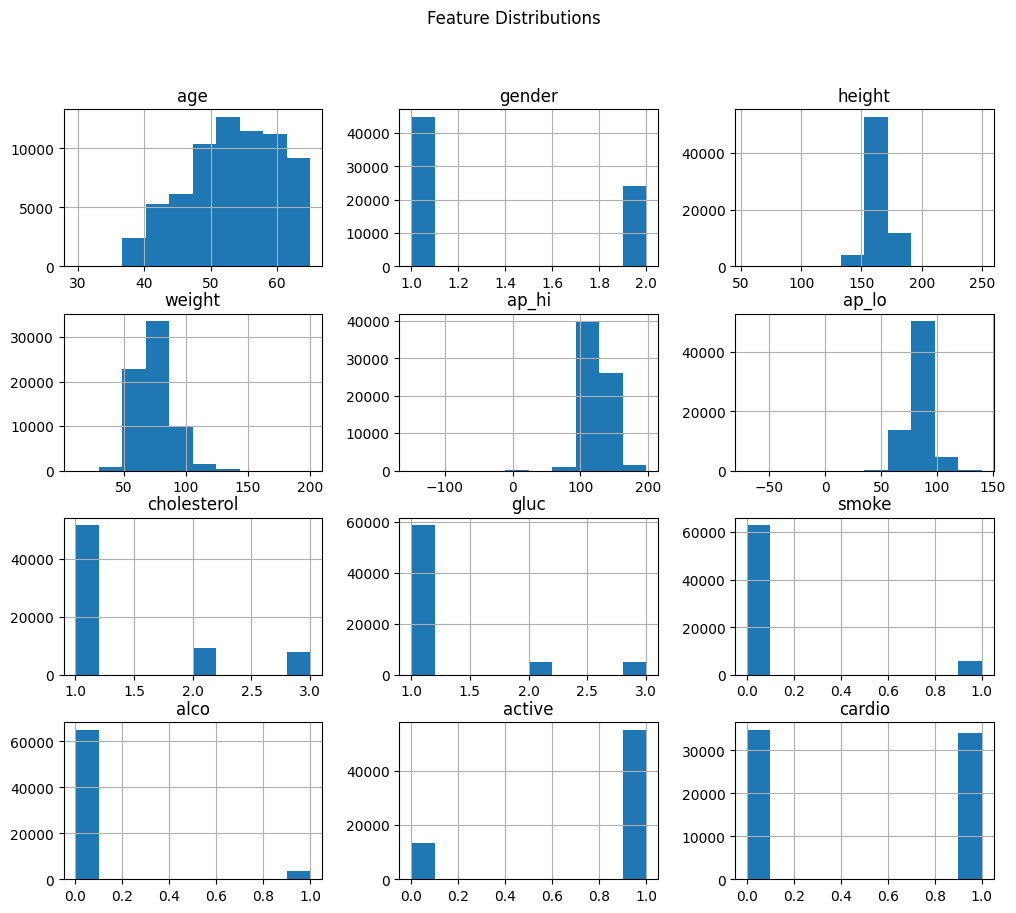

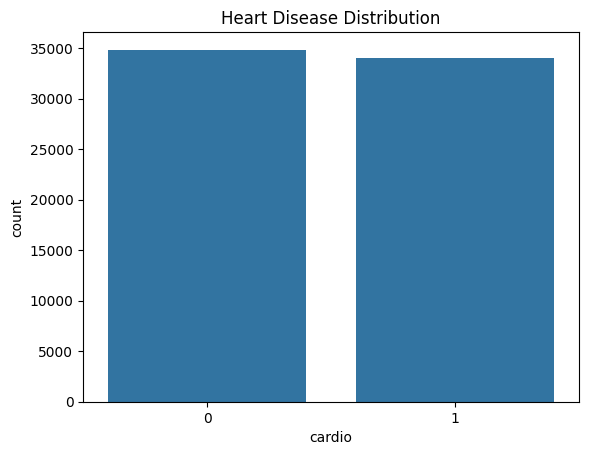

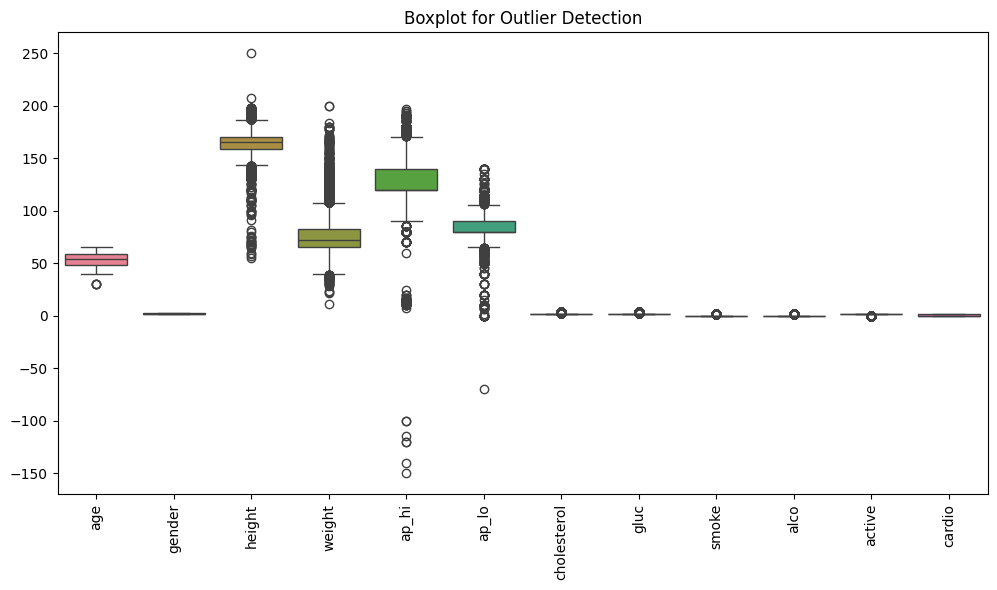

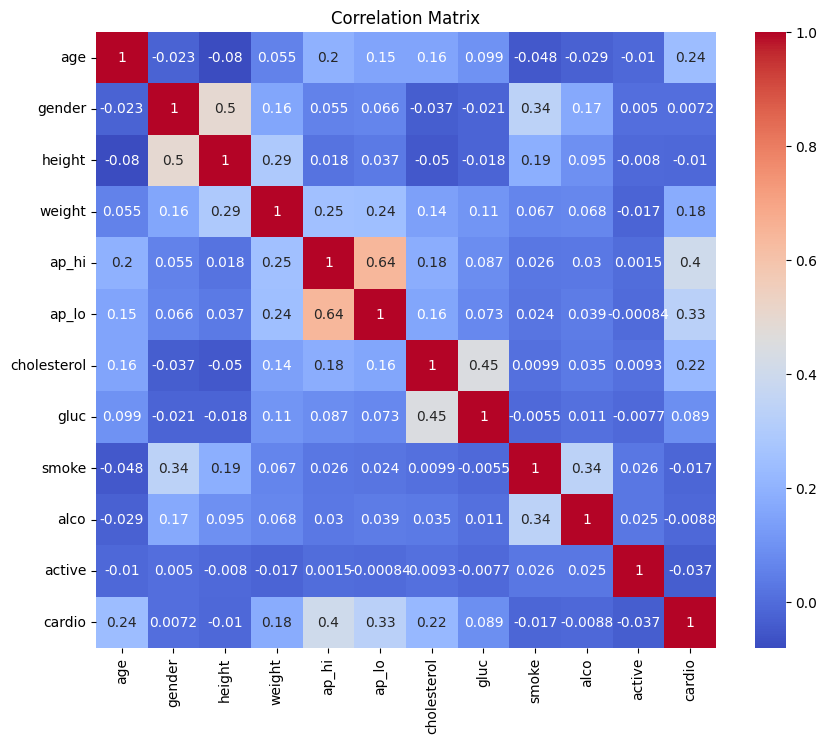


Logistic Regression
Accuracy: 0.7244860899251834
Confusion Matrix:
 [[5372 1567]
 [2226 4602]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74      6939
           1       0.75      0.67      0.71      6828

    accuracy                           0.72     13767
   macro avg       0.73      0.72      0.72     13767
weighted avg       0.73      0.72      0.72     13767


KNN
Accuracy: 0.6910728553788044
Confusion Matrix:
 [[4845 2094]
 [2159 4669]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.70      0.69      6939
           1       0.69      0.68      0.69      6828

    accuracy                           0.69     13767
   macro avg       0.69      0.69      0.69     13767
weighted avg       0.69      0.69      0.69     13767


Decision Tree
Accuracy: 0.6402992663615893
Confusion Matrix:
 [[4438 2501]
 [2451 4377]]
Classification Report:
         

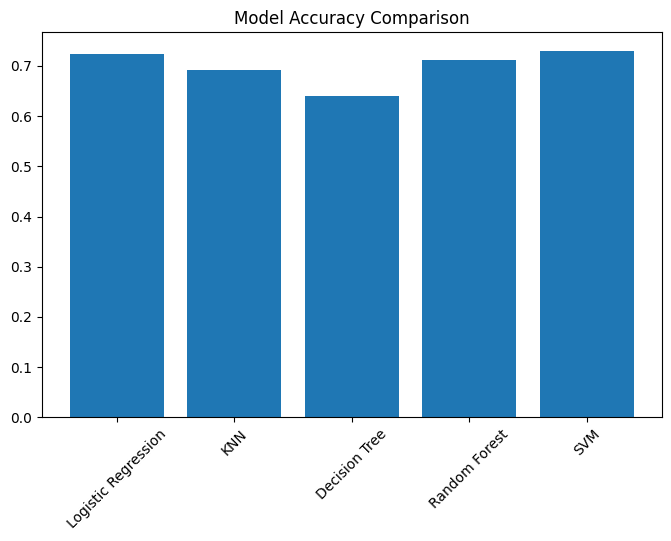


Final Accuracy Results:
 {'Logistic Regression': 0.7244860899251834, 'KNN': 0.6910728553788044, 'Decision Tree': 0.6402992663615893, 'Random Forest': 0.7127188203675455, 'SVM': 0.7304423621704075}

Best Model: SVM

Sample Prediction: No Heart Disease


C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# =========================================
# CARDIOVASCULAR DISEASE PREDICTION PROJECT
# =========================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# 2. LOAD DATASET
df = pd.read_csv('cardio_train (1).csv', sep=';')

print("Dataset Shape:", df.shape)
print(df.head())


# 3. DATA PREPROCESSING
# Drop ID column
df = df.drop('id', axis=1)

# Convert age from days to years
df['age'] = df['age'] / 365

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Remove unrealistic outliers (important step)
df = df[(df['ap_hi'] < 200) & (df['ap_lo'] < 150)]

print("After Cleaning Shape:", df.shape)


# 4. DATA VISUALIZATION

# Histograms
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

# Countplot (Target variable)
sns.countplot(x='cardio', data=df)
plt.title("Heart Disease Distribution")
plt.show()

# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()


# 5. CORRELATION MATRIX
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# 6. SPLIT DATA
X = df.drop('cardio', axis=1)
y = df['cardio']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# 7. TRAIN MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("\n==============================")
    print(name)
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


# 8. ACCURACY COMPARISON
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()

print("\nFinal Accuracy Results:\n", results)


# 9. BEST MODEL
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)


# 10. FINAL PREDICTION FUNCTION
def predict_heart_disease(input_data):
    input_data = np.array(input_data).reshape(1, -1)
    input_data = scaler.transform(input_data)
    prediction = best_model.predict(input_data)

    if prediction[0] == 1:
        return "Heart Disease Detected"
    else:
        return "No Heart Disease"


# Example prediction
sample = X.iloc[0]
print("\nSample Prediction:", predict_heart_disease(sample))